In [1]:
import xarray as xr
import torch
import pandas as pd 
# import numpy as np
# import matplotlib.pyplot as plt

In [20]:
# device='cuda'
# basepath_init = '/glade/derecho/scratch/wchapman/CREDIT_runs/wxformermod_sharp_SpatPS_pxshf/init_times/'
# ICs = torch.load(basepath_init+'init_be21_condition_tensor_1981-01-01T00Z.pth', map_location=torch.device(device))
# ICs.shape
# plt.pcolor(np.array(ICs[0,131,0,:,:].cpu()))
# plt.colorbar()
# plt.show()
# base_path = '/glade/derecho/scratch/kjmayer/CUVACAR/'
# climofi = base_path+'b.e21.CREDIT_climate_branch_1980-2014climo_zmdata_ERA5scaled_zmdata_Qtot.zarr'
# climo = xr.open_zarr(climofi)
# ICs[0,0:32,0,:,:] = torch.tensor(climo['U'][0].values).squeeze()
# ICs[0,32:64,0,:,:] = torch.tensor(climo['V'][0].values).squeeze()
# ICs[0,64:96,0,:,:] = torch.tensor(climo['T'][0].values).squeeze()
# ICs[0,96:128,0,:,:] = torch.tensor(climo['Qtot'][0].values).squeeze()

# ICs[0,128,0,:,:] = torch.tensor(climo['PS'][0].values).squeeze()
# ICs[0,129,0,:,:] = torch.tensor(climo['TREFHT'][0].values).squeeze()

# ICs[0,-1,0,:,:] = torch.tensor(climo['co2vmr_3d'][0].values).squeeze()
# ICs[0,-2,0,:,:] = torch.tensor(climo['ICEFRAC'][0].values).squeeze()
# ICs[0,-3,0,:,:] = torch.tensor(climo['SST'][0].values).squeeze()
# ICs[0,-4,0,:,:] = torch.tensor(climo['SOLIN'][0].values).squeeze()
# torch.save(ICs, '/glade/derecho/scratch/kjmayer/CUVACAR/init_be21_condition_tensor_baseline.pth')

## create base line ICS

In [2]:
TIME_Init = pd.date_range(start='1981-01-01', end = '1981-12-31', freq='6H')
DS = xr.open_zarr('/glade/derecho/scratch/wchapman/CUVACAR/b.e21.CREDIT_climate_branch_1980-2014climo_zmdata_ERA5scaled_zmdata_Qtot_v3.zarr')

/glade/derecho/scratch/kjmayer/tmp/ipykernel_14165/1226196686.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  TIME_Init = pd.date_range(start='1981-01-01', end = '1981-12-31', freq='6H')


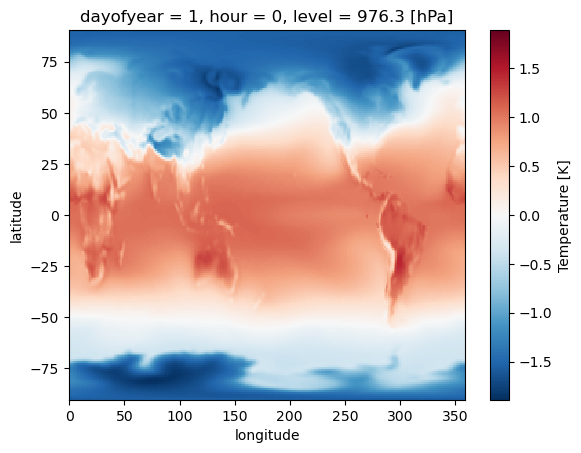

In [8]:
DS['T'].sel(hour=0, dayofyear=1, level=976.3, method='nearest').plot()

In [51]:
# BASELINE!!!!
hr_dict = {'0':0,'6':1,'12':2,'18':3}

for tt in TIME_Init:

    hr_sel = hr_dict[str(tt.hour)]
    device='cpu'
    basepath_init = '/glade/derecho/scratch/wchapman/CREDIT_runs/wxformermod_sharp_SpatPS_pxshf/init_times/'
    ICs = torch.load(basepath_init+'init_be21_condition_tensor_1981-01-01T00Z.pth', map_location=torch.device(device))

    ICs[0,0:32,0,:,:] = torch.tensor(DS['U'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,32:64,0,:,:] = torch.tensor(DS['V'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,64:96,0,:,:] = torch.tensor(DS['T'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,96:128,0,:,:] = torch.tensor(DS['Qtot'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    
    ICs[0,128,0,:,:] = torch.tensor(DS['PS'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,129,0,:,:] = torch.tensor(DS['TREFHT'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    
    ICs[0,-1,0,:,:] = torch.tensor(DS['co2vmr_3d'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,-2,0,:,:] = torch.tensor(DS['ICEFRAC'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,-3,0,:,:] = torch.tensor(DS['SST'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()
    ICs[0,-4,0,:,:] = torch.tensor(DS['SOLIN'].sel(dayofyear=tt.dayofyear)[hr_sel].values).squeeze()

    fout= f"/glade/derecho/scratch/wchapman/CUVACAR/init_{str(tt).replace(' ', '_').replace(':','_')}_be21_condition_tensor_baseline.pth"
    torch.save(ICs, fout)
    
    print(f'saved: {fout}') 

In [4]:
# INITS !!!!
base_path = '/glade/campaign/cisl/aiml/wchapman/MLWPS/STAGING/'
mean_data_fi = base_path+'mean_6h_1980_Coupled_2000_2012_32lev_1.0deg_ERA5scaled_F32_Qtot_Mixed_Modal.nc'
std_data_fi = base_path+'std_6h_1980_Coupled_2000_2012_32lev_1.0deg_ERA5scaled_F32_Qtot_Mixed_Modal.nc'
mean = xr.open_dataset(mean_data_fi)
std = xr.open_dataset(std_data_fi)

TIME_Init = pd.date_range(start='1981-01-01', end = '1981-12-31', freq='6H')
hr_dict = {'0':0,'6':1,'12':2,'18':3}
DS = xr.open_zarr('/glade/campaign/cisl/aiml/wchapman/MLWPS/STAGING/b.e21.CREDIT_climate_branch_1980_2014_zmdata_ERA5scaled_zmdata_Qtot.zarr')
DS = (DS - mean)/std
for tt in TIME_Init:

    hr_sel = hr_dict[str(tt.hour)]
    device='cpu'
    basepath_init = '/glade/derecho/scratch/wchapman/CREDIT_runs/wxformermod_sharp_SpatPS_pxshf/init_times/'
    ICs = torch.load(basepath_init+'init_be21_condition_tensor_1981-01-01T00Z.pth', map_location=torch.device(device))

    ICs[0,0:32,0,:,:] = torch.tensor(DS['U'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,32:64,0,:,:] = torch.tensor(DS['V'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,64:96,0,:,:] = torch.tensor(DS['T'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,96:128,0,:,:] = torch.tensor(DS['Qtot'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    
    ICs[0,128,0,:,:] = torch.tensor(DS['PS'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,129,0,:,:] = torch.tensor(DS['TREFHT'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    
    ICs[0,-1,0,:,:] = torch.tensor(DS['co2vmr_3d'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,-2,0,:,:] = torch.tensor(DS['ICEFRAC'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,-3,0,:,:] = torch.tensor(DS['SST'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()
    ICs[0,-4,0,:,:] = torch.tensor(DS['SOLIN'].where(DS.time.dt.dayofyear == tt.dayofyear, drop=True)[hr_sel].values).squeeze()

    fout= f"/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_{str(tt).replace(' ', '_').replace(':','_')}_be21_condition_tensor.pth"
    torch.save(ICs, fout)
    
    print(f'saved: {fout}') 

saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-01_00_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-01_06_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-01_12_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-01_18_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-02_00_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-02_06_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-02_12_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-02_18_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-01-03_00_00_00_be21_condition_tensor.pth
saved: /glade/derecho/scratch/kjmayer